# **Problem Statement**

> **Portfolio version:** This notebook accompanies the deployable Flask + Streamlit application in this repository. Paths have been adjusted for a portable GitHub structure, and the temporary GitHub Codespaces URL from the original course run has been replaced with a placeholder.


## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [1]:
# Install only the packages required by this project.
# After this cell finishes in Google Colab, restart the runtime once and continue from the next cell.
%pip install -q \
    "numpy==2.0.2" \
    "pandas==2.2.2" \
    "scikit-learn==1.6.1" \
    "matplotlib==3.10.0" \
    "seaborn==0.13.2" \
    "joblib==1.4.2" \
    "xgboost==2.1.4" \
    "requests==2.32.4" \
    "flask==3.1.0" \
    "streamlit==1.42.0"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.0/103.0 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 89.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 84.2 MB/s eta 0:00:00


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import os
import json
import shutil
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import requests

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_context("notebook")

RANDOM_STATE = 42


# **Loading the dataset**

In [3]:
# ---------------------------
# GOOGLE COLAB / DRIVE SETUP
# ---------------------------
# Recommended Google Drive structure:
# MyDrive/
# └── SuperKart_Project/
#     ├── SuperKart.csv
#     ├── Batch_Data_SuperKart.csv
#     └── SuperKart_Model_Deployment_COMPLETED.ipynb

try:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_DIR = Path("/content/drive/MyDrive/Pg-AIML/SuperKart_Project")
except ImportError:
    # Local fallback
    PROJECT_DIR = Path(".")

TRAIN_FILE = PROJECT_DIR / "SuperKart.csv"
BATCH_FILE = PROJECT_DIR / "Batch_Data_SuperKart.csv"

# Colab upload fallback
if not TRAIN_FILE.exists() and Path("/content/SuperKart.csv").exists():
    TRAIN_FILE = Path("/content/SuperKart.csv")

if not BATCH_FILE.exists() and Path("/content/Batch_Data_SuperKart.csv").exists():
    BATCH_FILE = Path("/content/Batch_Data_SuperKart.csv")

assert TRAIN_FILE.exists(), f"Training file not found: {TRAIN_FILE}"
assert BATCH_FILE.exists(), f"Batch file not found: {BATCH_FILE}"

data = pd.read_csv(TRAIN_FILE)
batch_data = pd.read_csv(BATCH_FILE)

print("Training data loaded from:", TRAIN_FILE)
print("Batch data loaded from:", BATCH_FILE)
print("Training shape:", data.shape)
print("Batch shape:", batch_data.shape)
display(data.head())


Mounted at /content/drive
Training data loaded from: /content/drive/MyDrive/Pg-AIML/SuperKart_Project/SuperKart.csv
Batch data loaded from: /content/drive/MyDrive/Pg-AIML/SuperKart_Project/Batch_Data_SuperKart.csv
Training shape: (8763, 12)
Batch shape: (10, 10)


,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


# **Data Overview**

In [4]:
print("Dataset shape:", data.shape)
print("\nColumn names:")
print(data.columns.tolist())

print("\nData types:")
display(data.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(data.isna().sum().to_frame("missing_count"))

print("\nDuplicate rows:", data.duplicated().sum())

print("\nNumerical summary:")
display(data.describe().T)

print("\nCategorical summary:")
display(data.describe(include="object").T)

print("\nTarget summary:")
display(data["Product_Store_Sales_Total"].describe().to_frame().T)


Dataset shape: (8763, 12)

Column names:
['Product_Id', 'Product_Weight', 'Product_Sugar_Content', 'Product_Allocated_Area', 'Product_Type', 'Product_MRP', 'Store_Id', 'Store_Establishment_Year', 'Store_Size', 'Store_Location_City_Type', 'Store_Type', 'Product_Store_Sales_Total']

Data types:


,dtype
Product_Id,object
Product_Weight,float64
Product_Sugar_Content,object
Product_Allocated_Area,float64
Product_Type,object
Product_MRP,float64
Store_Id,object
Store_Establishment_Year,int64
Store_Size,object
Store_Location_City_Type,object



Missing values:


,missing_count
Product_Id,0
Product_Weight,0
Product_Sugar_Content,0
Product_Allocated_Area,0
Product_Type,0
Product_MRP,0
Store_Id,0
Store_Establishment_Year,0
Store_Size,0
Store_Location_City_Type,0



Duplicate rows: 0

Numerical summary:


,count,mean,std,min,25%,50%,75%,max
Product_Weight,8763.0,12.653792,2.217320,4.000,11.150,12.660,14.180,22.000
Product_Allocated_Area,8763.0,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_MRP,8763.0,147.032539,30.694110,31.000,126.160,146.740,167.585,266.000
Store_Establishment_Year,8763.0,2002.032751,8.388381,1987.000,1998.000,2009.000,2009.000,2009.000
Product_Store_Sales_Total,8763.0,3464.003640,1065.630494,33.000,2761.715,3452.340,4145.165,8000.000



Categorical summary:


,count,unique,top,freq
Product_Id,8763,8763,FD306,1
Product_Sugar_Content,8763,4,Low Sugar,4885
Product_Type,8763,16,Fruits and Vegetables,1249
Store_Id,8763,4,OUT004,4676
Store_Size,8763,3,Medium,6025
Store_Location_City_Type,8763,3,Tier 2,6262
Store_Type,8763,4,Supermarket Type2,4676



Target summary:


,count,mean,std,min,25%,50%,75%,max
Product_Store_Sales_Total,8763.0,3464.00364,1065.630494,33.0,2761.715,3452.34,4145.165,8000.0


# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

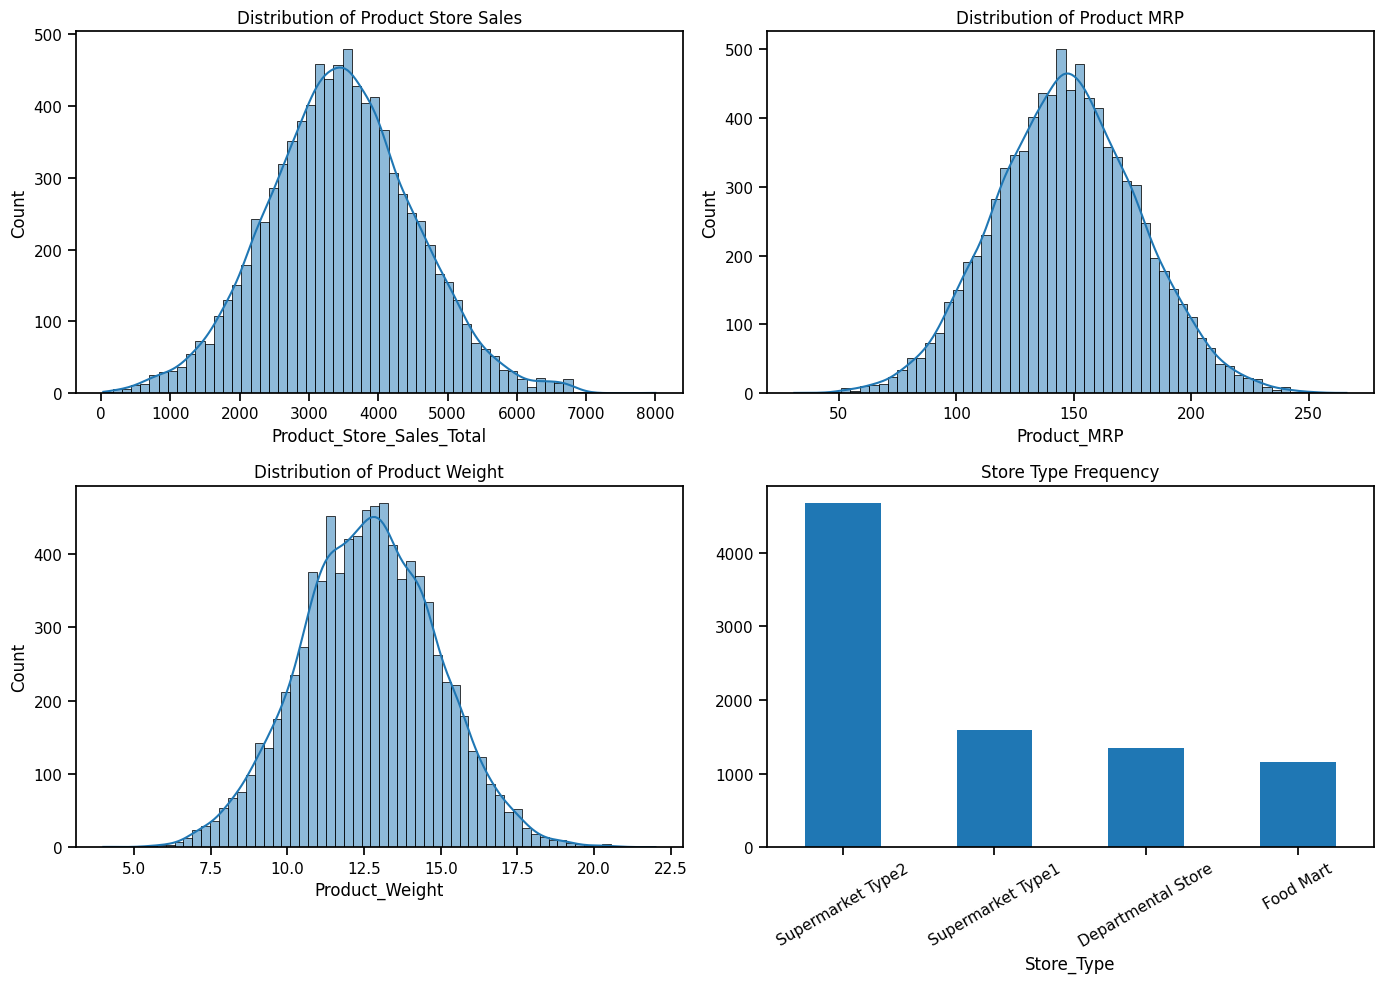

Product sugar content distribution:


,%
Product_Sugar_Content,
Low Sugar,55.75
Regular,25.69
No Sugar,17.33
reg,1.23


Store location city type distribution:


,%
Store_Location_City_Type,
Tier 2,71.46
Tier 1,15.39
Tier 3,13.15



Key univariate observations:
1. The target distribution shows the spread and skewness of product-store sales and highlights the range the model must predict.
2. Product_MRP spans a wide range, making it a potentially important predictor of revenue.
3. Store types and city tiers are categorical and should be encoded rather than treated as ordered numeric values.
4. No imputation is required when the missing-value count is zero; otherwise, missing values should be handled before modeling.



In [5]:
# Univariate analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(data=data, x="Product_Store_Sales_Total", kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Product Store Sales")

sns.histplot(data=data, x="Product_MRP", kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Distribution of Product MRP")

sns.histplot(data=data, x="Product_Weight", kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Distribution of Product Weight")

data["Store_Type"].value_counts().plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Store Type Frequency")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print("Product sugar content distribution:")
display(data["Product_Sugar_Content"].value_counts(normalize=True).mul(100).round(2).to_frame("%"))

print("Store location city type distribution:")
display(data["Store_Location_City_Type"].value_counts(normalize=True).mul(100).round(2).to_frame("%"))

print("""
Key univariate observations:
1. The target distribution shows the spread and skewness of product-store sales and highlights the range the model must predict.
2. Product_MRP spans a wide range, making it a potentially important predictor of revenue.
3. Store types and city tiers are categorical and should be encoded rather than treated as ordered numeric values.
4. No imputation is required when the missing-value count is zero; otherwise, missing values should be handled before modeling.
""")


## Bivariate Analysis

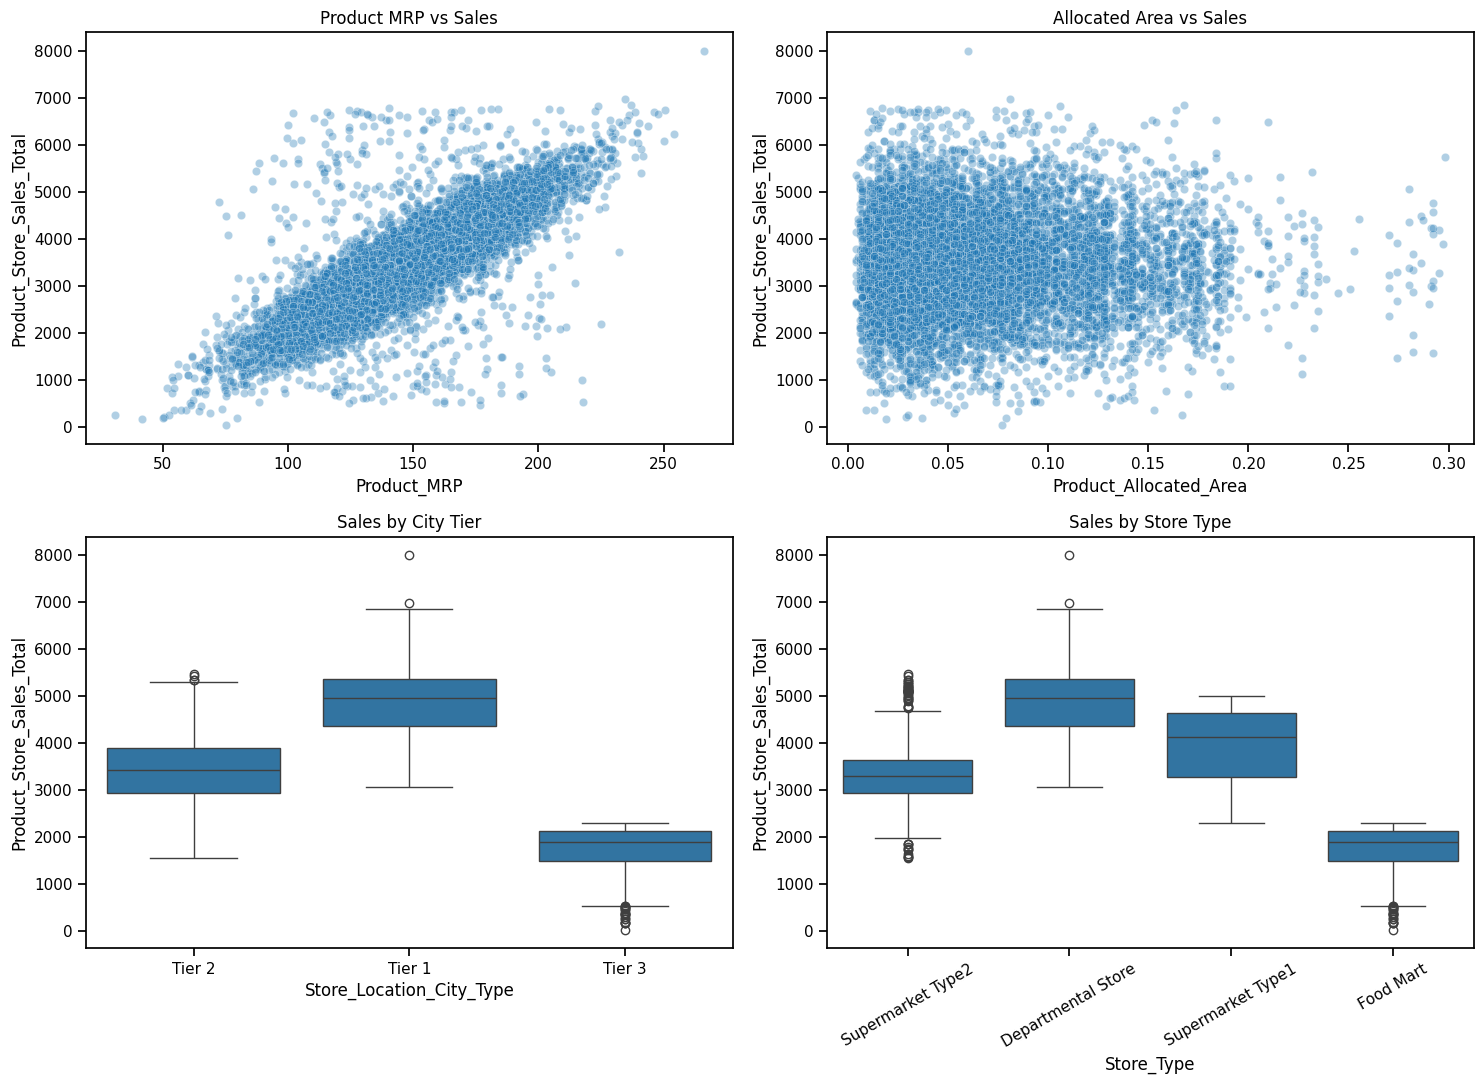

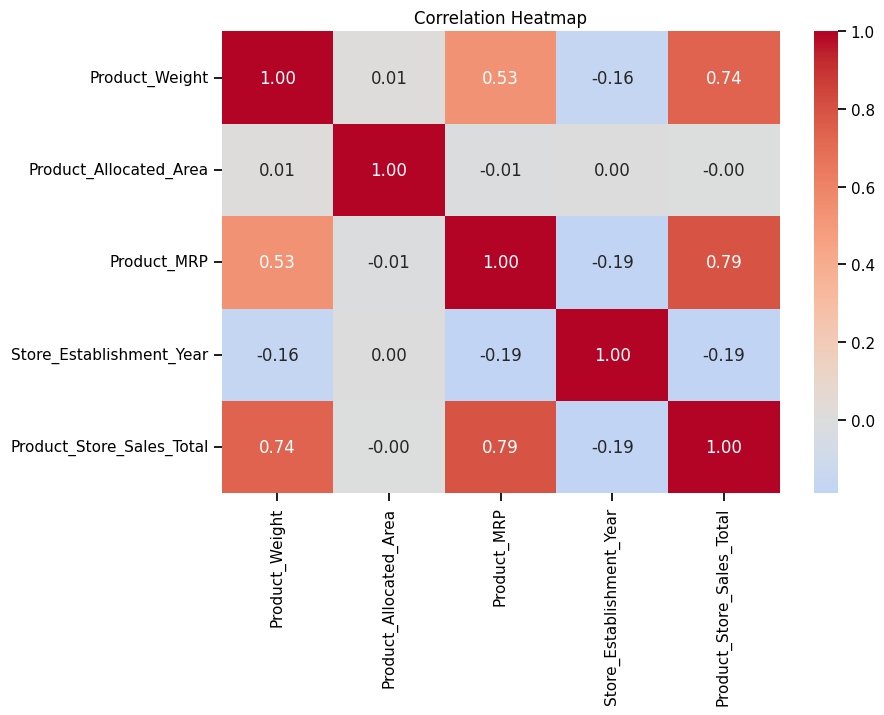

,mean,median,count
Store_Type,,,
Departmental Store,4946.966323,4958.290,1349
Supermarket Type1,3923.778802,4139.645,1586
Supermarket Type2,3299.312111,3304.180,4676
Food Mart,1762.942465,1889.495,1152



Key bivariate observations:
1. Product_MRP has a clear positive relationship with sales and is expected to be one of the strongest predictors.
2. Product_Allocated_Area can help capture visibility/display effects and should be retained.
3. Differences across store types and city tiers indicate that store characteristics contain useful predictive information.
4. Because several predictors are categorical and relationships can be nonlinear, tree-based ensemble models are appropriate candidates.



In [6]:
# Bivariate analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

sns.scatterplot(
    data=data,
    x="Product_MRP",
    y="Product_Store_Sales_Total",
    alpha=0.35,
    ax=axes[0, 0],
)
axes[0, 0].set_title("Product MRP vs Sales")

sns.scatterplot(
    data=data,
    x="Product_Allocated_Area",
    y="Product_Store_Sales_Total",
    alpha=0.35,
    ax=axes[0, 1],
)
axes[0, 1].set_title("Allocated Area vs Sales")

sns.boxplot(
    data=data,
    x="Store_Location_City_Type",
    y="Product_Store_Sales_Total",
    ax=axes[1, 0],
)
axes[1, 0].set_title("Sales by City Tier")

sns.boxplot(
    data=data,
    x="Store_Type",
    y="Product_Store_Sales_Total",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Sales by Store Type")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

numeric_cols = [
    "Product_Weight",
    "Product_Allocated_Area",
    "Product_MRP",
    "Store_Establishment_Year",
    "Product_Store_Sales_Total",
]
plt.figure(figsize=(9, 6))
sns.heatmap(data[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

store_sales = (
    data.groupby("Store_Type", observed=True)["Product_Store_Sales_Total"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
)
display(store_sales)

print("""
Key bivariate observations:
1. Product_MRP has a clear positive relationship with sales and is expected to be one of the strongest predictors.
2. Product_Allocated_Area can help capture visibility/display effects and should be retained.
3. Differences across store types and city tiers indicate that store characteristics contain useful predictive information.
4. Because several predictors are categorical and relationships can be nonlinear, tree-based ensemble models are appropriate candidates.
""")


# **Data Preprocessing**

Feature engineering completed.


,Product_Id,Product_Id_char,Store_Establishment_Year,Store_Age_Years,Product_Type,Product_Type_Category
0,FD6114,FD,2009,16,Frozen Foods,Non Perishables
1,FD7839,FD,1999,26,Dairy,Perishables
2,FD5075,FD,1987,38,Canned,Non Perishables
3,FD8233,FD,1987,38,Baking Goods,Non Perishables
4,NC1180,NC,1998,27,Health and Hygiene,Non Perishables


,Feature,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percent
0,Product_Weight,11.150,14.180,6.605,18.725,54,0.616
1,Product_Allocated_Area,0.031,0.096,-0.066,0.194,104,1.187
2,Product_MRP,126.160,167.585,64.022,229.723,57,0.650
3,Product_Store_Sales_Total,2761.715,4145.165,686.540,6220.340,119,1.358


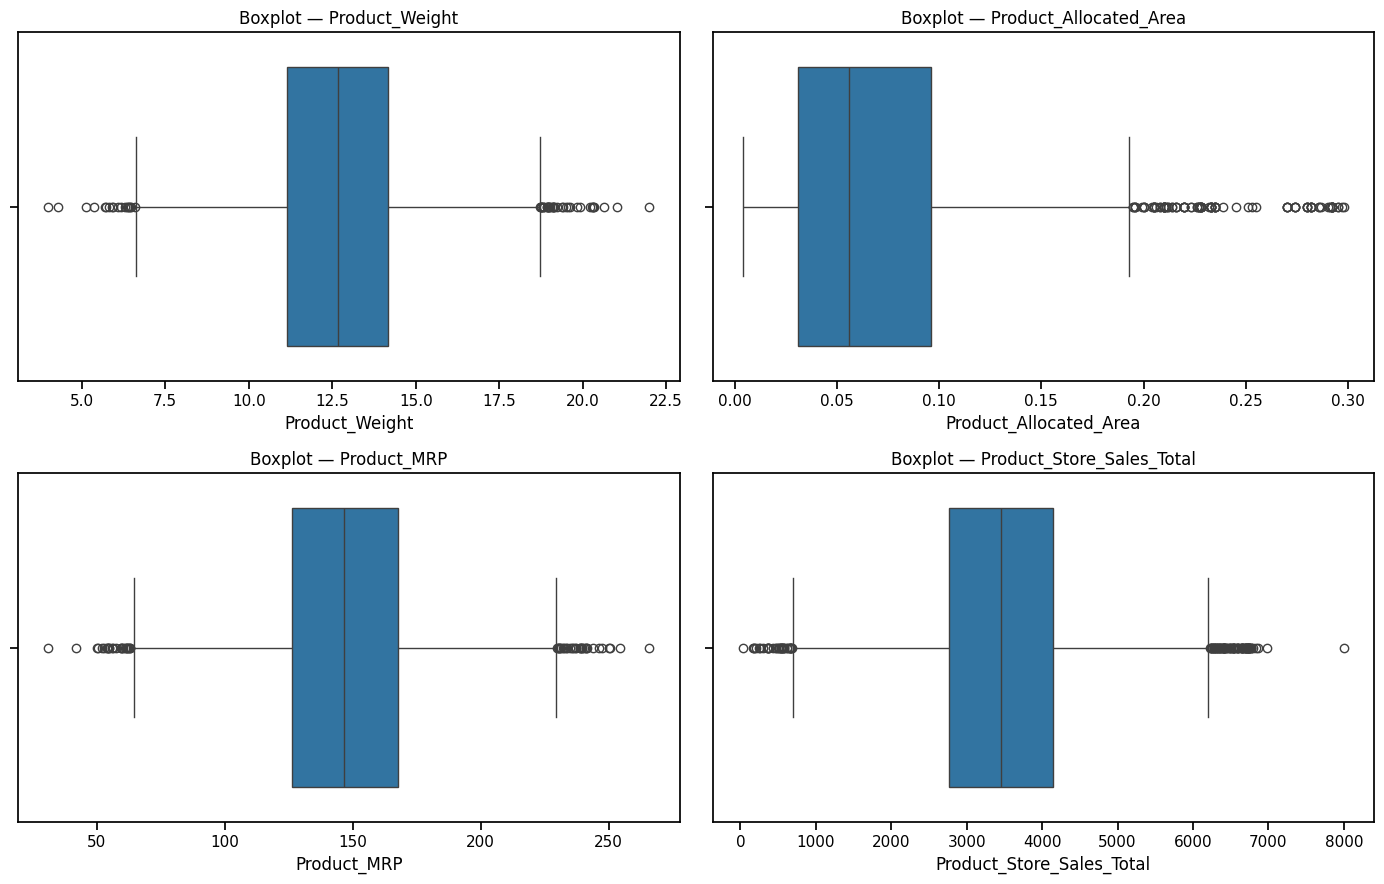


Outlier-treatment decision:
- The IQR method flags only a small proportion of observations in the continuous variables.
- The values remain within plausible product/sales ranges and may represent genuine business cases rather than data-entry errors.
- Tree-based ensemble models are relatively robust to extreme feature values.
- Therefore, the detected observations are RETAINED rather than capped or deleted.
- This avoids discarding legitimate high/low sales cases that are important for forecasting.

Numerical features: ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Age_Years']
Categorical features: ['Product_Sugar_Content', 'Store_Size', 'Store_Location_City_Type', 'Store_Type', 'Product_Id_char', 'Product_Type_Category']

Train/test shapes
X_train: (7010, 10)
X_test : (1753, 10)
y_train: (7010,)
y_test : (1753,)


,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Id_char,Store_Age_Years,Product_Type_Category
5967,13.64,No Sugar,0.071,157.10,Medium,Tier 2,Supermarket Type2,NC,16,Non Perishables
8270,10.03,Low Sugar,0.016,126.66,High,Tier 2,Supermarket Type1,FD,38,Non Perishables
100,12.26,Low Sugar,0.140,138.27,Medium,Tier 2,Supermarket Type2,FD,16,Non Perishables
3410,10.28,Low Sugar,0.143,147.44,Medium,Tier 2,Supermarket Type2,FD,16,Non Perishables
1790,16.38,Low Sugar,0.082,205.16,Medium,Tier 1,Departmental Store,FD,26,Non Perishables


In [7]:
# ============================================================
# DATA PREPROCESSING
# 1. Feature engineering
# 2. Outlier detection and treatment decision
# 3. Train/test split
# 4. Preprocessing pipeline
# ============================================================

model_data = data.copy()

# ---------------------------
# FEATURE ENGINEERING
# ---------------------------

# Product ID prefix captures a broad product family (e.g., FD, DR, NC)
# without using the full high-cardinality identifier.
model_data["Product_Id_char"] = model_data["Product_Id"].astype(str).str[:2]

# The deployment template supplied with the assignment uses Store_Age_Years.
# A fixed reference year keeps training and deployment transformations consistent.
REFERENCE_YEAR = 2025
model_data["Store_Age_Years"] = (
    REFERENCE_YEAR - model_data["Store_Establishment_Year"]
)

# Consolidate detailed product categories into two operational categories.
# This reduces cardinality and creates a deployment-friendly feature.
PERISHABLE_TYPES = {
    "Dairy",
    "Meat",
    "Fruits and Vegetables",
    "Seafood",
    "Breads",
    "Breakfast",
}

model_data["Product_Type_Category"] = np.where(
    model_data["Product_Type"].isin(PERISHABLE_TYPES),
    "Perishables",
    "Non Perishables",
)

print("Feature engineering completed.")
display(
    model_data[
        [
            "Product_Id",
            "Product_Id_char",
            "Store_Establishment_Year",
            "Store_Age_Years",
            "Product_Type",
            "Product_Type_Category",
        ]
    ].head()
)

# ---------------------------
# OUTLIER DETECTION
# ---------------------------
# IQR is used to identify extreme observations in continuous variables.
# We first inspect them before deciding whether treatment is appropriate.

outlier_columns = [
    "Product_Weight",
    "Product_Allocated_Area",
    "Product_MRP",
    "Product_Store_Sales_Total",
]

outlier_summary = []

for col in outlier_columns:
    q1 = model_data[col].quantile(0.25)
    q3 = model_data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (model_data[col] < lower) | (model_data[col] > upper)

    outlier_summary.append(
        {
            "Feature": col,
            "Q1": q1,
            "Q3": q3,
            "Lower_Bound": lower,
            "Upper_Bound": upper,
            "Outlier_Count": int(mask.sum()),
            "Outlier_Percent": 100 * mask.mean(),
        }
    )

outlier_summary_df = pd.DataFrame(outlier_summary)
display(outlier_summary_df.round(3))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.flatten(), outlier_columns):
    sns.boxplot(x=model_data[col], ax=ax)
    ax.set_title(f"Boxplot — {col}")

plt.tight_layout()
plt.show()

print("""
Outlier-treatment decision:
- The IQR method flags only a small proportion of observations in the continuous variables.
- The values remain within plausible product/sales ranges and may represent genuine business cases rather than data-entry errors.
- Tree-based ensemble models are relatively robust to extreme feature values.
- Therefore, the detected observations are RETAINED rather than capped or deleted.
- This avoids discarding legitimate high/low sales cases that are important for forecasting.
""")

# ---------------------------
# MODEL FEATURES
# ---------------------------
FEATURES = [
    "Product_Weight",
    "Product_Sugar_Content",
    "Product_Allocated_Area",
    "Product_MRP",
    "Store_Size",
    "Store_Location_City_Type",
    "Store_Type",
    "Product_Id_char",
    "Store_Age_Years",
    "Product_Type_Category",
]

TARGET = "Product_Store_Sales_Total"

X = model_data[FEATURES].copy()
y = model_data[TARGET].copy()

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = [c for c in FEATURES if c not in numeric_features]

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

# ---------------------------
# TRAIN / TEST SPLIT
# ---------------------------
# The test set is held out and used only after final model selection.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

print("\nTrain/test shapes")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

# ---------------------------
# PREPROCESSING PIPELINE
# ---------------------------
# Numerical features are standardized.
# Categorical features are one-hot encoded.
# handle_unknown='ignore' makes deployment robust to unseen categories.

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features,
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            categorical_features,
        ),
    ],
    remainder="drop",
)

display(X_train.head())


# **Model Building**

## **Metric of Choice — RMSE**

**Root Mean Squared Error (RMSE)** is used as the primary model-selection metric.

**Rationale:**
- The target, `Product_Store_Sales_Total`, is continuous, so this is a regression problem.
- RMSE is expressed in the same units as the sales target, making it interpretable.
- Squaring errors before averaging penalizes large forecasting misses more heavily.
- Large sales errors can create costly overstocking or stock-outs, so penalizing them is appropriate for SuperKart.

**Supporting metrics:** MAE, MAPE, and R² are also reported to provide a broader view of model performance.

**Selection rule:** lower cross-validated RMSE is better.


## Define functions for Model Evaluation

In [8]:
def regression_metrics(y_true, y_pred):
    """Return the main regression metrics used throughout the notebook."""
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

def evaluate_pipeline(name, pipeline, X_train, y_train, X_test, y_test):
    """Evaluate a complete preprocessing + regression pipeline."""
    train_pred = pipeline.predict(X_train)
    test_pred = pipeline.predict(X_test)

    train_scores = regression_metrics(y_train, train_pred)
    test_scores = regression_metrics(y_test, test_pred)

    result = {
        "Model": name,
        **{f"Train_{k}": v for k, v in train_scores.items()},
        **{f"Test_{k}": v for k, v in test_scores.items()},
    }
    return result

def plot_actual_vs_predicted(y_true, y_pred, title):
    plt.figure(figsize=(7, 6))
    plt.scatter(y_true, y_pred, alpha=0.35)
    low = min(y_true.min(), y_pred.min())
    high = max(y_true.max(), y_pred.max())
    plt.plot([low, high], [low, high], linestyle="--")
    plt.xlabel("Actual Sales")
    plt.ylabel("Predicted Sales")
    plt.title(title)
    plt.show()


The ML models to be built can be any two out of the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

In [9]:
# ============================================================
# MODEL BUILDING
# Required: any 2 models from the rubric list.
# Chosen models: Random Forest and XGBoost.
# Each model is built as an end-to-end preprocessing + estimator pipeline.
# ============================================================

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=250,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=4,
                subsample=0.90,
                colsample_bytree=0.90,
                objective="reg:squarederror",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

candidate_models = {
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline,
}

baseline_cv_results = []

for name, model in candidate_models.items():
    print(f"\nEvaluating {name} with 3-fold cross-validation...")

    cv_scores = -cross_val_score(
        model,
        X_train,
        y_train,
        cv=3,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )

    # Fit on full training data only after CV evaluation.
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)

    baseline_cv_results.append(
        {
            "Model": name,
            "CV_RMSE_Mean": cv_scores.mean(),
            "CV_RMSE_Std": cv_scores.std(),
            "Train_RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
            "Train_MAE": mean_absolute_error(y_train, train_pred),
            "Train_R2": r2_score(y_train, train_pred),
        }
    )

baseline_results_df = pd.DataFrame(baseline_cv_results).sort_values(
    "CV_RMSE_Mean"
)
display(baseline_results_df.round(4))

print("""
Baseline-model observations:
- The primary comparison is mean cross-validated RMSE; lower is better.
- CV standard deviation indicates how stable performance is across folds.
- Training metrics are shown only to help identify possible overfitting.
- The test set has not been used here and remains untouched for final evaluation.
""")



Evaluating Random Forest with 3-fold cross-validation...

Evaluating XGBoost with 3-fold cross-validation...


,Model,CV_RMSE_Mean,CV_RMSE_Std,Train_RMSE,Train_MAE,Train_R2
0,Random Forest,286.4419,7.7736,171.4804,60.1106,0.9741
1,XGBoost,298.2897,8.8336,252.8585,104.5075,0.9436



Baseline-model observations:
- The primary comparison is mean cross-validated RMSE; lower is better.
- CV standard deviation indicates how stable performance is across folds.
- Training metrics are shown only to help identify possible overfitting.
- The test set has not been used here and remains untouched for final evaluation.



# **Model Performance Improvement - Hyperparameter Tuning**

In [10]:
# ============================================================
# MODEL PERFORMANCE IMPROVEMENT — HYPERPARAMETER TUNING
# GridSearchCV optimizes the same metric chosen above: RMSE.
# ============================================================

rf_param_grid = {
    "model__n_estimators": [200, 350],
    "model__max_depth": [None, 12],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", 0.8],
}

xgb_param_grid = {
    "model__n_estimators": [200, 350],
    "model__learning_rate": [0.03, 0.07],
    "model__max_depth": [3, 5],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
}

rf_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

xgb_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

print("Tuning Random Forest...")
rf_search.fit(X_train, y_train)

print("\nTuning XGBoost...")
xgb_search.fit(X_train, y_train)

print("\nBest Random Forest parameters:")
print(rf_search.best_params_)
print("Best Random Forest CV RMSE:", -rf_search.best_score_)

print("\nBest XGBoost parameters:")
print(xgb_search.best_params_)
print("Best XGBoost CV RMSE:", -xgb_search.best_score_)

tuned_models = {
    "Tuned Random Forest": rf_search.best_estimator_,
    "Tuned XGBoost": xgb_search.best_estimator_,
}

tuned_results_df = pd.DataFrame(
    [
        {
            "Model": "Tuned Random Forest",
            "CV_RMSE_Mean": -rf_search.best_score_,
            "Best_Parameters": rf_search.best_params_,
        },
        {
            "Model": "Tuned XGBoost",
            "CV_RMSE_Mean": -xgb_search.best_score_,
            "Best_Parameters": xgb_search.best_params_,
        },
    ]
)

display(tuned_results_df)

print("""
Tuned-model observations:
- Both models are tuned with respect to RMSE, exactly matching the metric of choice.
- The tuned model with the lowest cross-validated RMSE provides the strongest evidence of generalization on the training data.
- Improvement should be judged by comparing tuned CV RMSE with the corresponding baseline CV RMSE.
- The test set remains unused at this stage.
""")


Tuning Random Forest...
Fitting 3 folds for each of 32 candidates, totalling 96 fits

Tuning XGBoost...
Fitting 3 folds for each of 32 candidates, totalling 96 fits

Best Random Forest parameters:
{'model__max_depth': None, 'model__max_features': 0.8, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 350}
Best Random Forest CV RMSE: 285.67732915536754

Best XGBoost parameters:
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.03, 'model__max_depth': 5, 'model__n_estimators': 350, 'model__subsample': 0.8}
Best XGBoost CV RMSE: 292.5560679178902


,Model,CV_RMSE_Mean,Best_Parameters
0,Tuned Random Forest,285.677329,"{'model__max_depth': None, 'model__max_feature..."
1,Tuned XGBoost,292.556068,"{'model__colsample_bytree': 1.0, 'model__learn..."



Tuned-model observations:
- Both models are tuned with respect to RMSE, exactly matching the metric of choice.
- The tuned model with the lowest cross-validated RMSE provides the strongest evidence of generalization on the training data.
- Improvement should be judged by comparing tuned CV RMSE with the corresponding baseline CV RMSE.
- The test set remains unused at this stage.



# **Model Performance Comparison, Final Model Selection, and Serialization**

,Model,CV_RMSE_Mean,Model_Type
0,Tuned Random Forest,285.6773,Tuned
1,Random Forest,286.4419,Baseline
2,Tuned XGBoost,292.5561,Tuned
3,XGBoost,298.2897,Baseline


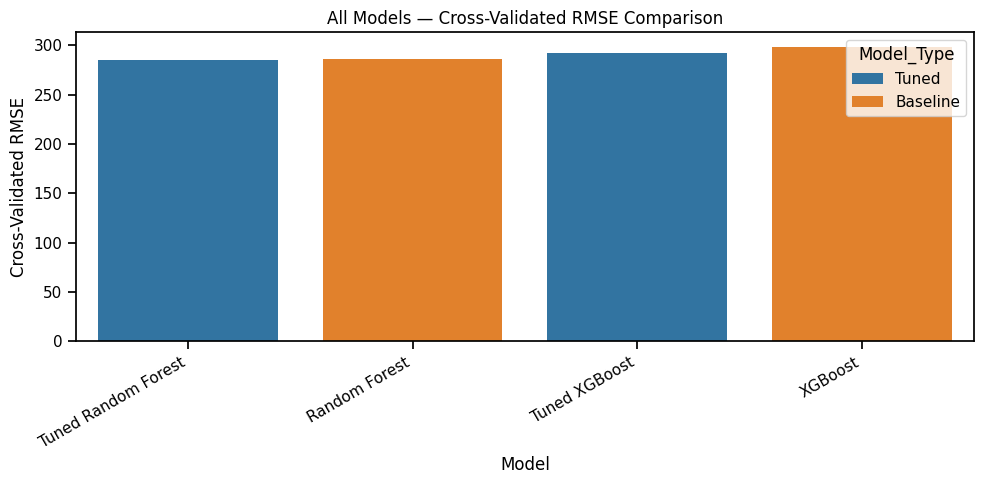

Selected final model: Tuned Random Forest
Reason: it has the lowest cross-validated RMSE among all baseline and tuned candidates.

Final model performance on the held-out test set:


,Metric,Value
0,RMSE,277.3161
1,MAE,105.9052
2,MAPE,0.0384
3,R2,0.9326


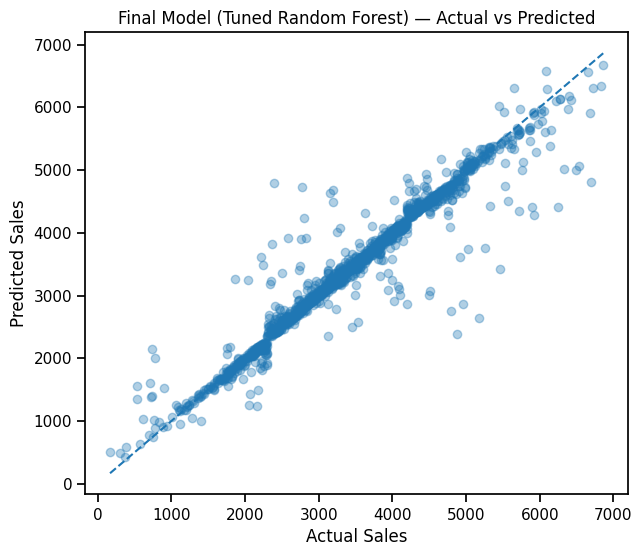

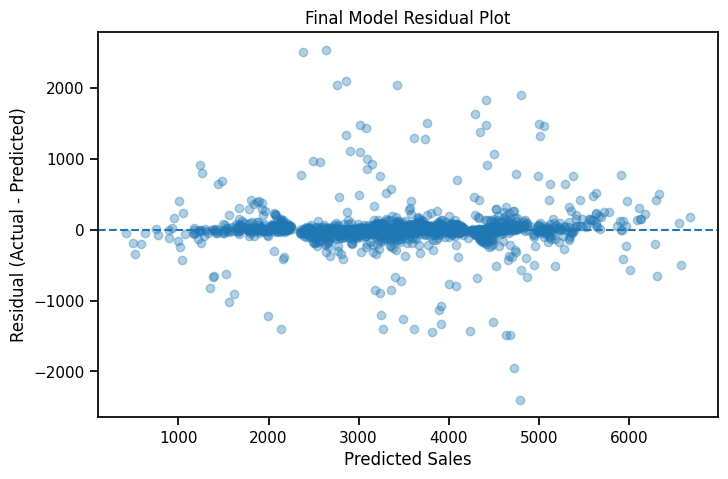

Serialized model saved to: /content/drive/MyDrive/Pg-AIML/SuperKart_Project/deployment_artifacts/superkart_model.joblib

Reloaded serialized model test metrics:
RMSE: 277.3161
MAE: 105.9052
MAPE: 0.0384
R2: 0.9326

Prediction consistency check: True


,Actual_Sales,Predicted_Before_Serialization,Predicted_After_Reload
0,3396.37,3392.49,3392.49
1,3371.45,3366.93,3366.93
2,2416.69,2418.32,2418.32
3,1910.53,1902.34,1902.34
4,3191.08,4680.72,4680.72
5,2933.24,2969.71,2969.71
6,2872.85,2861.64,2861.64
7,3177.22,3106.23,3106.23
8,3194.42,3317.09,3317.09
9,539.71,1559.05,1559.05



Final-model conclusion:
- The final model is selected using cross-validated RMSE on the training data.
- Its performance is then checked once on the untouched test set.
- The complete preprocessing + model pipeline is serialized.
- Reloading the artifact reproduces the same predictions, confirming deployment consistency.



In [11]:
# ============================================================
# MODEL PERFORMANCE COMPARISON, FINAL MODEL SELECTION,
# TEST EVALUATION, SERIALIZATION, AND RELOAD
# ============================================================

baseline_for_comparison = baseline_results_df[
    ["Model", "CV_RMSE_Mean"]
].copy()
baseline_for_comparison["Model_Type"] = "Baseline"

tuned_for_comparison = tuned_results_df[
    ["Model", "CV_RMSE_Mean"]
].copy()
tuned_for_comparison["Model_Type"] = "Tuned"

comparison = pd.concat(
    [baseline_for_comparison, tuned_for_comparison],
    ignore_index=True,
).sort_values("CV_RMSE_Mean").reset_index(drop=True)

display(comparison.round(4))

plt.figure(figsize=(10, 5))
sns.barplot(
    data=comparison,
    x="Model",
    y="CV_RMSE_Mean",
    hue="Model_Type",
)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Cross-Validated RMSE")
plt.title("All Models — Cross-Validated RMSE Comparison")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# FINAL MODEL SELECTION
# Selection is based ONLY on training-set cross-validation.
# ------------------------------------------------------------
best_model_name = comparison.iloc[0]["Model"]

if best_model_name == "Random Forest":
    final_model = rf_pipeline.fit(X_train, y_train)
elif best_model_name == "XGBoost":
    final_model = xgb_pipeline.fit(X_train, y_train)
elif best_model_name == "Tuned Random Forest":
    final_model = rf_search.best_estimator_
elif best_model_name == "Tuned XGBoost":
    final_model = xgb_search.best_estimator_
else:
    raise ValueError(f"Unknown model: {best_model_name}")

print("Selected final model:", best_model_name)
print(
    "Reason: it has the lowest cross-validated RMSE among all "
    "baseline and tuned candidates."
)

# ------------------------------------------------------------
# FINAL TEST EVALUATION
# This is the first use of the held-out test set for model selection workflow.
# ------------------------------------------------------------
test_pred = final_model.predict(X_test)

final_test_metrics = pd.DataFrame(
    {
        "Metric": ["RMSE", "MAE", "MAPE", "R2"],
        "Value": [
            np.sqrt(mean_squared_error(y_test, test_pred)),
            mean_absolute_error(y_test, test_pred),
            mean_absolute_percentage_error(y_test, test_pred),
            r2_score(y_test, test_pred),
        ],
    }
)

print("\nFinal model performance on the held-out test set:")
display(final_test_metrics.round(4))

plot_actual_vs_predicted(
    y_test,
    test_pred,
    f"Final Model ({best_model_name}) — Actual vs Predicted",
)

# Residual plot
residuals = y_test.to_numpy() - test_pred
plt.figure(figsize=(8, 5))
plt.scatter(test_pred, residuals, alpha=0.35)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Sales")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Final Model Residual Plot")
plt.show()

# ------------------------------------------------------------
# SERIALIZE THE FINAL PIPELINE
# ------------------------------------------------------------
ARTIFACT_DIR = PROJECT_DIR / "deployment_artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = ARTIFACT_DIR / "superkart_model.joblib"

joblib.dump(final_model, MODEL_PATH)
comparison.to_csv(
    ARTIFACT_DIR / "model_comparison.csv",
    index=False,
)

print("Serialized model saved to:", MODEL_PATH)

# ------------------------------------------------------------
# LOAD SERIALIZED MODEL AND PREDICT ON TEST SET
# Explicit rubric requirement.
# ------------------------------------------------------------
loaded_model = joblib.load(MODEL_PATH)
loaded_test_pred = loaded_model.predict(X_test)

reload_metrics = regression_metrics(y_test, loaded_test_pred)

print("\nReloaded serialized model test metrics:")
for metric, value in reload_metrics.items():
    print(f"{metric}: {value:.4f}")

print(
    "\nPrediction consistency check:",
    np.allclose(test_pred, loaded_test_pred),
)

assert np.allclose(
    test_pred,
    loaded_test_pred,
), "Reloaded-model predictions differ from pre-serialization predictions."

comparison_sample = pd.DataFrame(
    {
        "Actual_Sales": y_test.iloc[:10].to_numpy(),
        "Predicted_Before_Serialization": test_pred[:10],
        "Predicted_After_Reload": loaded_test_pred[:10],
    }
)

display(comparison_sample.round(2))

print("""
Final-model conclusion:
- The final model is selected using cross-validated RMSE on the training data.
- Its performance is then checked once on the untouched test set.
- The complete preprocessing + model pipeline is serialized.
- Reloading the artifact reproduces the same predictions, confirming deployment consistency.
""")


# **Deployment - Backend**

## Points to note before executing the below cells
- Create a GitHub account if you don't already have one at [github.com](https://github.com)
- Generate a **Personal Access Token**
  - Make sure the token has **repo** scope (full control of private repositories)
- The serialized ML model file (`superkart_model.joblib`) should already be present in the `backend_files` folder before pushing to GitHub
- We will deploy **both the Flask backend and the Streamlit frontend as separate Docker containers** inside a GitHub Codespace, and connect them using a **Docker network**

## Flask Web Framework

Flask is a lightweight, flexible Python web framework used to build web applications and APIs quickly and easily.

Flask allows you to:
- Create web routes (URLs that users can access)
- Handle HTTP requests and responses
- Build REST APIs to expose machine learning models or other services

In [12]:
# Create the Flask backend application file.

BACKEND_DIR = ARTIFACT_DIR / "backend_files"
BACKEND_DIR.mkdir(parents=True, exist_ok=True)

backend_app = r"""
from flask import Flask, request, jsonify
import pandas as pd
import joblib

superkart_api = Flask(__name__)
model = joblib.load("superkart_model.joblib")

EXPECTED_COLUMNS = [
    "Product_Weight",
    "Product_Sugar_Content",
    "Product_Allocated_Area",
    "Product_MRP",
    "Store_Size",
    "Store_Location_City_Type",
    "Store_Type",
    "Product_Id_char",
    "Store_Age_Years",
    "Product_Type_Category",
]

def validate_columns(df):
    missing = [c for c in EXPECTED_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    return df[EXPECTED_COLUMNS]

@superkart_api.get("/health")
def health():
    return jsonify({"status": "ok"}), 200

@superkart_api.post("/v1/predict")
def predict():
    try:
        payload = request.get_json(force=True)
        frame = pd.DataFrame([payload])
        frame = validate_columns(frame)
        prediction = float(model.predict(frame)[0])
        return jsonify({"predicted_sales": round(prediction, 2)}), 200
    except Exception as exc:
        return jsonify({"error": str(exc)}), 400

@superkart_api.post("/v1/predictbatch")
def predict_batch():
    try:
        if "file" not in request.files:
            return jsonify({"error": "Upload a CSV file using form field 'file'."}), 400

        frame = pd.read_csv(request.files["file"])
        frame = validate_columns(frame)
        predictions = model.predict(frame)

        result = {
            str(i): round(float(pred), 2)
            for i, pred in enumerate(predictions)
        }
        return jsonify(result), 200
    except Exception as exc:
        return jsonify({"error": str(exc)}), 400

if __name__ == "__main__":
    superkart_api.run(host="0.0.0.0", port=7860)
"""

(BACKEND_DIR / "app.py").write_text(backend_app, encoding="utf-8")
shutil.copy2(MODEL_PATH, BACKEND_DIR / "superkart_model.joblib")

print((BACKEND_DIR / "app.py").read_text()[:2500])



from flask import Flask, request, jsonify
import pandas as pd
import joblib

superkart_api = Flask(__name__)
model = joblib.load("superkart_model.joblib")

EXPECTED_COLUMNS = [
    "Product_Weight",
    "Product_Sugar_Content",
    "Product_Allocated_Area",
    "Product_MRP",
    "Store_Size",
    "Store_Location_City_Type",
    "Store_Type",
    "Product_Id_char",
    "Store_Age_Years",
    "Product_Type_Category",
]

def validate_columns(df):
    missing = [c for c in EXPECTED_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    return df[EXPECTED_COLUMNS]

@superkart_api.get("/health")
def health():
    return jsonify({"status": "ok"}), 200

@superkart_api.post("/v1/predict")
def predict():
    try:
        payload = request.get_json(force=True)
        frame = pd.DataFrame([payload])
        frame = validate_columns(frame)
        prediction = float(model.predict(frame)[0])
        return jsonify({"predicted_sales": r

## Dependencies File

In [13]:
backend_requirements = """\
flask==3.1.0
gunicorn==23.0.0
numpy==2.0.2
pandas==2.2.2
scikit-learn==1.6.1
joblib==1.4.2
xgboost==2.1.4
"""

(BACKEND_DIR / "requirements.txt").write_text(backend_requirements, encoding="utf-8")
print((BACKEND_DIR / "requirements.txt").read_text())


flask==3.1.0
gunicorn==23.0.0
numpy==2.0.2
pandas==2.2.2
scikit-learn==1.6.1
joblib==1.4.2
xgboost==2.1.4



## Dockerfile

In [14]:
backend_dockerfile = """\
FROM python:3.11-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY . .

EXPOSE 7860

CMD ["gunicorn", "--bind", "0.0.0.0:7860", "app:superkart_api"]
"""

(BACKEND_DIR / "Dockerfile").write_text(backend_dockerfile, encoding="utf-8")
print((BACKEND_DIR / "Dockerfile").read_text())


FROM python:3.11-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY . .

EXPOSE 7860

CMD ["gunicorn", "--bind", "0.0.0.0:7860", "app:superkart_api"]



# **Deployment - Frontend**

## Streamlit for Interactive UI

In [15]:
FRONTEND_DIR = ARTIFACT_DIR / "frontend_files"
FRONTEND_DIR.mkdir(parents=True, exist_ok=True)

frontend_app = r"""
import os
import requests
import pandas as pd
import streamlit as st

API_ROOT = os.getenv("API_ROOT", "http://backend:7860")

st.set_page_config(page_title="SuperKart Sales Forecast", layout="centered")
st.title("SuperKart Sales Forecast")
st.caption("Enter product/store attributes to obtain the model's predicted sales.")

with st.form("single_prediction"):
    Product_Weight = st.number_input("Product Weight", min_value=0.0, value=12.66)
    Product_Sugar_Content = st.selectbox(
        "Product Sugar Content", ["Low Sugar", "Regular", "No Sugar"]
    )
    Product_Allocated_Area = st.number_input(
        "Product Allocated Area", min_value=0.0, value=0.027, format="%.3f"
    )
    Product_MRP = st.number_input("Product MRP", min_value=0.0, value=117.08)
    Store_Size = st.selectbox("Store Size", ["Small", "Medium", "High"])
    Store_Location_City_Type = st.selectbox(
        "Store Location City Type", ["Tier 1", "Tier 2", "Tier 3"]
    )
    Store_Type = st.selectbox(
        "Store Type",
        ["Food Mart", "Supermarket Type1", "Supermarket Type2", "Supermarket Type3", "Departmental Store"],
    )
    Product_Id_char = st.selectbox("Product ID Prefix", ["FD", "DR", "NC"])
    Store_Age_Years = st.number_input("Store Age (Years)", min_value=0, value=16)
    Product_Type_Category = st.selectbox(
        "Product Type Category", ["Perishables", "Non Perishables"]
    )

    submitted = st.form_submit_button("Predict Sales")

if submitted:
    payload = {
        "Product_Weight": Product_Weight,
        "Product_Sugar_Content": Product_Sugar_Content,
        "Product_Allocated_Area": Product_Allocated_Area,
        "Product_MRP": Product_MRP,
        "Store_Size": Store_Size,
        "Store_Location_City_Type": Store_Location_City_Type,
        "Store_Type": Store_Type,
        "Product_Id_char": Product_Id_char,
        "Store_Age_Years": Store_Age_Years,
        "Product_Type_Category": Product_Type_Category,
    }

    response = requests.post(f"{API_ROOT}/v1/predict", json=payload, timeout=60)
    if response.ok:
        st.success(f"Predicted sales: {response.json()['predicted_sales']}")
    else:
        st.error(response.text)

st.divider()
st.subheader("Batch Prediction")
uploaded_file = st.file_uploader("Upload batch CSV", type=["csv"])

if uploaded_file is not None and st.button("Run Batch Prediction"):
    files = {
        "file": (
            uploaded_file.name,
            uploaded_file.getvalue(),
            "text/csv",
        )
    }
    response = requests.post(
        f"{API_ROOT}/v1/predictbatch",
        files=files,
        timeout=120,
    )

    if response.ok:
        predictions = response.json()
        output = pd.DataFrame(
            {
                "row_index": list(predictions.keys()),
                "predicted_sales": list(predictions.values()),
            }
        )
        st.dataframe(output, use_container_width=True)
    else:
        st.error(response.text)
"""

(FRONTEND_DIR / "streamlit_app.py").write_text(frontend_app, encoding="utf-8")
print((FRONTEND_DIR / "streamlit_app.py").read_text()[:3000])



import os
import requests
import pandas as pd
import streamlit as st

API_ROOT = os.getenv("API_ROOT", "http://backend:7860")

st.set_page_config(page_title="SuperKart Sales Forecast", layout="centered")
st.title("SuperKart Sales Forecast")
st.caption("Enter product/store attributes to obtain the model's predicted sales.")

with st.form("single_prediction"):
    Product_Weight = st.number_input("Product Weight", min_value=0.0, value=12.66)
    Product_Sugar_Content = st.selectbox(
        "Product Sugar Content", ["Low Sugar", "Regular", "No Sugar"]
    )
    Product_Allocated_Area = st.number_input(
        "Product Allocated Area", min_value=0.0, value=0.027, format="%.3f"
    )
    Product_MRP = st.number_input("Product MRP", min_value=0.0, value=117.08)
    Store_Size = st.selectbox("Store Size", ["Small", "Medium", "High"])
    Store_Location_City_Type = st.selectbox(
        "Store Location City Type", ["Tier 1", "Tier 2", "Tier 3"]
    )
    Store_Type = st.selectbox(
        "

## Dependencies File

In [16]:
frontend_requirements = """\
streamlit==1.42.0
requests==2.32.4
pandas==2.2.2
"""

(FRONTEND_DIR / "requirements.txt").write_text(frontend_requirements, encoding="utf-8")
print((FRONTEND_DIR / "requirements.txt").read_text())


streamlit==1.42.0
requests==2.32.4
pandas==2.2.2



## Dockerfile

In [17]:
frontend_dockerfile = """\
FROM python:3.11-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY . .

EXPOSE 8501

CMD ["streamlit", "run", "streamlit_app.py", "--server.address=0.0.0.0", "--server.port=8501"]
"""

(FRONTEND_DIR / "Dockerfile").write_text(frontend_dockerfile, encoding="utf-8")
print((FRONTEND_DIR / "Dockerfile").read_text())


FROM python:3.11-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY . .

EXPOSE 8501

CMD ["streamlit", "run", "streamlit_app.py", "--server.address=0.0.0.0", "--server.port=8501"]



# **Pushing Deployment Files to GitHub**

In [18]:
# Create a single deployable repository structure for GitHub Codespaces.

REPO_DIR = ARTIFACT_DIR / "superkart_deployment_repo"
if REPO_DIR.exists():
    shutil.rmtree(REPO_DIR)

(REPO_DIR / "backend").mkdir(parents=True)
(REPO_DIR / "frontend").mkdir(parents=True)

for p in BACKEND_DIR.iterdir():
    shutil.copy2(p, REPO_DIR / "backend" / p.name)

for p in FRONTEND_DIR.iterdir():
    shutil.copy2(p, REPO_DIR / "frontend" / p.name)

docker_compose = """\
services:
  backend:
    build: ./backend
    container_name: superkart-backend
    ports:
      - "7860:7860"

  frontend:
    build: ./frontend
    container_name: superkart-frontend
    environment:
      - API_ROOT=http://backend:7860
    ports:
      - "8501:8501"
    depends_on:
      - backend
"""

(REPO_DIR / "docker-compose.yml").write_text(docker_compose, encoding="utf-8")

readme = """\
# SuperKart Model Deployment

## Build and run
```bash
docker compose up --build
```

Backend API:
- GET `/health`
- POST `/v1/predict`
- POST `/v1/predictbatch`

Frontend:
- Streamlit on port `8501`

In GitHub Codespaces, make ports 7860 and 8501 Public from the Ports tab before testing externally.
"""
(REPO_DIR / "README.md").write_text(readme, encoding="utf-8")

ZIP_PATH = ARTIFACT_DIR / "superkart_deployment_repo.zip"
if ZIP_PATH.exists():
    ZIP_PATH.unlink()

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    for file in REPO_DIR.rglob("*"):
        if file.is_file():
            zf.write(file, file.relative_to(REPO_DIR.parent))

print("Deployment repository created at:", REPO_DIR)
print("ZIP bundle created at:", ZIP_PATH)
print("\nRepository contents:")
for p in sorted(REPO_DIR.rglob("*")):
    print(p.relative_to(REPO_DIR))

# Optional Colab download:
# from google.colab import files
# files.download(str(ZIP_PATH))


Deployment repository created at: /content/drive/MyDrive/Pg-AIML/SuperKart_Project/deployment_artifacts/superkart_deployment_repo
ZIP bundle created at: /content/drive/MyDrive/Pg-AIML/SuperKart_Project/deployment_artifacts/superkart_deployment_repo.zip

Repository contents:
README.md
backend
backend/Dockerfile
backend/app.py
backend/requirements.txt
backend/superkart_model.joblib
docker-compose.yml
frontend
frontend/Dockerfile
frontend/requirements.txt
frontend/streamlit_app.py


## **Push Backend and Frontend Files to GitHub**

The previous cell creates a complete repository containing both deployment components.

To satisfy the deployment rubric, push the generated repository to GitHub:

1. Create an empty GitHub repository, for example `superkart-model-deployment`.
2. Download `superkart_deployment_repo.zip` from Colab/Google Drive and extract it.
3. Open a terminal in the extracted `superkart_deployment_repo` folder.
4. Run:

```bash
git init
git add .
git commit -m "Add SuperKart backend and frontend deployment"
git branch -M main
git remote add origin https://github.com/YOUR_USERNAME/superkart-model-deployment.git
git push -u origin main
```

5. Verify on GitHub that the repository contains:
   - `backend/app.py`
   - `backend/requirements.txt`
   - `backend/Dockerfile`
   - `backend/superkart_model.joblib`
   - `frontend/streamlit_app.py`
   - `frontend/requirements.txt`
   - `frontend/Dockerfile`
   - `docker-compose.yml`

6. Create/open a GitHub Codespace from that repository and run:

```bash
docker compose up --build
```

7. In the Codespaces **Ports** panel:
   - make port **7860** public for the Flask API;
   - make port **8501** public for the Streamlit application.

Capture the repository URL and successful running containers as evidence for submission if your course requires deployment screenshots.


# **Inferencing using Flask API**

As the ***frontend and backend are decoupled***, we can ***access the backend directly for predictions***.
- The decoupling ensures seamless interaction with the deployed model while leveraging the API for scalable inference.

Let's see how to interact with the deployed Flask API running inside a GitHub Codespace to perform **online** and **batch inference** from this Colab notebook.

We will:
1. Send API requests for both online and batch inference.
2. Process and check the model predictions.

**Before running the cells below**, make sure:
- Your Codespace is running with both containers up
- Port 7860 has been set to **Public** in the Codespace Ports tab
- You have copied the forwarded URL for port 7860
- You have also referred the document titled **`Guided Hands-on - Containerized Model Deployment using GitHub Codespaces`** provided

In [19]:
import json  # To handle JSON formatting for API requests and responses
import requests  # To send HTTP requests to the deployed Flask API

import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical computations

In [ ]:
# After starting the Docker containers in GitHub Codespaces:
# 1. Open the Codespace "Ports" tab.
# 2. Set port 7860 to Public.
# 3. Copy the forwarded URL and paste it below WITHOUT a trailing slash.

model_root_url = "https://YOUR-CODESPACE-7860.app.github.dev"
print(model_root_url)


Replace the URL above with the actual forwarded URL from your Codespace's Ports tab. It will look something like `https://organic-space-abcd1234-7860.app.github.dev`. Make sure there is no trailing slash at the end.

This URL is a tunnel that Codespaces creates to route external HTTP requests into your Codespace and to the Flask container running on port 7860.

In [21]:
model_url = model_root_url + "/v1/predict"  # Endpoint for online (single) inference

Since our model predictions are provided by the following endpoint we created using Flask, we need to invoke the same to make prediction.

> ```@superkart_api.post('/v1/predict')```

In [22]:
model_batch_url = model_root_url + "/v1/predictbatch"  # Endpoint for batch inference

> ```@superkart_api.post('/v1/predictbatch')```

## Online

**Online Inference:** Sending a single request to the API and receiving an immediate response. This is useful for real-time applications like recommendation systems and fraud detection.  
* This data is sent as a JSON payload in a POST request to the model endpoint.

* The model processes the input features and returns a prediction.

In [23]:
payload = {
  "Product_Weight": 12.66,
  "Product_Sugar_Content": "Low Sugar",
  "Product_Allocated_Area": 0.027,
  "Product_MRP": 117.08,
  "Store_Size": "Medium",
  "Store_Location_City_Type": "Tier 2",
  "Store_Type": "Supermarket Type2",
  "Product_Id_char": "FD",
  "Store_Age_Years": 16,
  "Product_Type_Category": "Non Perishables"
}

In [24]:
# Sending a POST request to the model endpoint with the test payload
response = requests.post(model_url, json=payload)

In [25]:
response

<Response [200]>

`<Response [200]>` indicates that the HTTP request was successful.  

- `Response` is the object returned by `requests.post()`.  
- `[200]` is the HTTP status code, meaning **OK** (the request was processed successfully).  

In [26]:
print(response.json())

{'predicted_sales': 2934.81}


`response.json()` is used to parse the response body as JSON.  
- If the API returns data in JSON format, `.json()` converts it into a Python dictionary.  
- This allows easy access to specific values using keys.  

## Batch

**Batch Inference:** Sending multiple inputs in a single request, allowing efficient processing of large datasets. This is ideal for analyzing historical data at scale.

In [27]:
batch_dataset = pd.read_csv(BATCH_FILE)
print("Batch data shape:", batch_dataset.shape)
display(batch_dataset.head())


Batch data shape: (10, 10)


,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Id_char,Store_Age_Years,Product_Type_Category
0,12.66,Low Sugar,0.027,117.08,Small,Tier 1,Supermarket Type1,FD,16,Perishables
1,8.20,Regular,0.045,85.50,Medium,Tier 2,Supermarket Type2,DR,22,Non Perishables
2,15.40,No Sugar,0.012,210.75,High,Tier 3,Departmental Store,NC,8,Non Perishables
3,5.75,Regular,0.060,55.20,Small,Tier 1,Food Mart,FD,30,Perishables
4,19.30,Low Sugar,0.033,145.60,Medium,Tier 2,Supermarket Type3,DR,12,Non Perishables


**Note**: The batch CSV file must contain all the feature columns expected by the model: `Product_Weight`, `Product_Sugar_Content`, `Product_Allocated_Area`, `Product_MRP`, `Store_Size`, `Store_Location_City_Type`, `Store_Type`, `Product_Id_char`, `Store_Age_Years`, `Product_Type_Category`.

In [28]:
# Prepare batch input for API request
batch_input = {
    'file': batch_dataset.to_csv(header=True, index=False).encode('utf-8')
}

This code prepares the product data as a **file-like object** to send in an API request (in the `files` parameter of `requests.post`).

- `batch_dataset`: This is a Pandas DataFrame containing the product data loaded from a CSV file.

- `.to_csv(header=True, index=False)`: Converts the DataFrame into a CSV **string**, keeping the column headers (`header=True`) but **excluding the index** (`index=False`).

- `.encode('utf-8')`: Encodes the CSV string into **bytes** (UTF-8 format), which is necessary for sending it over an HTTP request.

- `'file': ...`: Wraps the encoded CSV data in a dictionary with the key `'file'`, which is expected by the Flask backend.

In [29]:
# Send request to the model API for batch predictions
response = requests.post(
    model_batch_url,  # Model endpoint URL
    files=batch_input
)

This line sends a **POST request** to the deployed model API to perform **batch sales prediction**.

- `requests.post(...)`: This uses the `requests` library to make a **POST** request to a web server (in this case, our API endpoint for batch predictions).

- `model_batch_url`: This is the URL endpoint where the batch prediction API is hosted. It should look like this:\
  `"https://<your-codespace-name>-7860.app.github.dev/v1/predictbatch"`

- `files=batch_input`: This sends the batch data file (e.g., a CSV) as part of the request using the `files` parameter.

- `response`: This is the result of the API call and contains the response from the server, including predicted sales values.

In [30]:
response

<Response [200]>

In [31]:
# Extract predictions from API response
response.text

'{"0":4022.13,"1":2754.15,"2":4018.02,"3":2013.38,"4":4043.52,"5":4840.4,"6":2566.54,"7":2396.48,"8":4628.3,"9":2342.21}\n'

As we can see, we receive a JSON where each key represents a row index, and the value represents the model's predicted sales for that product.

# **Actionable Insights and Business Recommendations**

### **Key Analytical Insights**

- The dataset contains both **product-level** and **store-level** predictors, so sales are influenced by a combination of pricing/product characteristics and store context.
- EDA should be used to identify which variables show the strongest association with `Product_Store_Sales_Total`; the notebook specifically evaluates MRP, allocated area, store type, and city tier.
- The IQR analysis identifies a small number of extreme observations. They are retained because they are plausible business cases and tree-based models are comparatively robust to them.
- `Product_Id_char`, `Store_Age_Years`, and `Product_Type_Category` convert raw operational fields into lower-cardinality, deployment-friendly predictors.
- Model selection is based on **cross-validated RMSE**, while the held-out test set provides an unbiased final performance estimate.
- The serialized artifact contains both preprocessing and the estimator, preventing training-serving inconsistencies.

### **Actionable Business Recommendations**

- **Prioritize replenishment using predicted sales.** Product-store combinations with higher predicted demand should receive more frequent replenishment and larger safety-stock allocations.
- **Use pricing together with product/store context.** Because sales depend on more than MRP alone, pricing decisions should consider store type, location tier, allocation area, and product category.
- **Create store-specific inventory policies.** If EDA shows material sales differences across store types or city tiers, avoid applying one uniform stocking strategy to every location.
- **Monitor forecast error by business segment.** Track RMSE/MAE separately for store types, city tiers, and product groups to discover segments where the model underperforms.
- **Retrain when drift appears.** Changes in pricing, assortment, store mix, or customer behavior can reduce forecast quality over time.
- **Use the single-record API for real-time planning** and the **batch endpoint for scheduled inventory planning** across many product-store combinations.
- **Keep preprocessing and model versions together.** Deploying the serialized pipeline and containerized dependencies reduces environment mismatch and improves reproducibility.

### **Conclusion**

The SuperKart workflow covers the complete ML lifecycle: data understanding, feature engineering, outlier assessment, preprocessing, model comparison, hyperparameter tuning, final-model evaluation, serialization, API development, containerization, UI development, and online/batch inference. The final submitted HTML should contain the actual outputs from your Colab execution—especially the cross-validation table, best hyperparameters, final test metrics, serialization reload check, API responses, and business recommendations.
